In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [2]:
files = !ls ../Data/*.tsv
files = np.array(files)
for f in range(len(files)):
    print(f, files[f])

0 ../Data/16cm.tsv
1 ../Data/1Plate.tsv
2 ../Data/2cm.tsv
3 ../Data/2Plate.tsv
4 ../Data/32cm.tsv
5 ../Data/3Plate.tsv
6 ../Data/4cm.tsv
7 ../Data/4Plate.tsv
8 ../Data/50cm.tsv
9 ../Data/5Plate.tsv
10 ../Data/6Plate.tsv
11 ../Data/8cm.tsv
12 ../Data/Background_Cs137Gain.tsv
13 ../Data/Co60_Raw.tsv
14 ../Data/cs137raw.tsv
15 ../Data/MassAbsorptionBackground.tsv


# Spectra plotting

In [33]:
CsSpecF = '../Data/cs137raw.tsv'
CsBgF = '../Data/Background_Cs137Gain.tsv'
CoSpecF = '../Data/Co60_Raw.tsv'
CoBgF = '../Data/CoNaBackground.tsv'
NaSpecF = '../Data/'
NaBgF = '../Data/CoNaBackground.tsv'

In [34]:
CsSpec = (np.loadtxt(CsSpecF, delimiter="\t",skiprows=25)).T
CsBg = (np.loadtxt(CsBgF,skiprows=25)).T
CsSpec[-1] = CsSpec[-1] - CsBg[-1]
CoSpec = np.loadtxt(CoSpecF, delimiter="\t",skiprows=25).T
CoBg = np.loadtxt(CoBgF, delimiter="\t",skiprows=25).T
CoSpec[-1] = CoSpec[-1] - CoBg[-1]
NaSpec = np.zeros(CsSpec.shape)
NaBg = np.zeros(CsSpec.shape)

In [35]:
CoSpec[-1]

array([1.900e+01, 2.000e+00, 5.000e+00, ..., 3.221e+03, 3.285e+03,
       3.285e+03])

In [36]:
# Photopeak energies
PP_Cs = 0.667
PP_Co = 1.17
PP_Na = 1.276

PP_Vals = [PP_Cs, PP_Co, PP_Na]

# Energy interpolation calculation
dE_Cs = 0.0002045103491
dE_Na = 1
dE_Co = 1.17 / 3340

CsSpec[1] = CsSpec[0] * dE_Cs
CoSpec[1] = CoSpec[0] * dE_Co
NaSpec[1] = NaSpec[0] * dE_Na


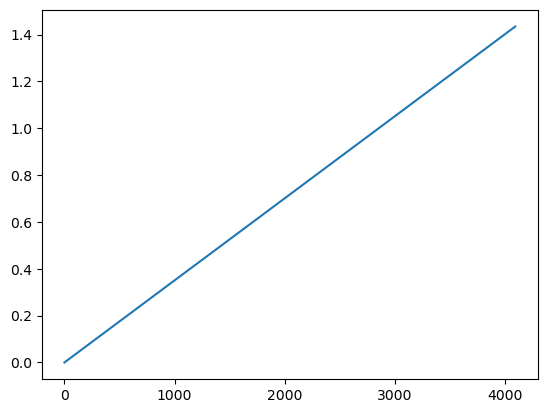

In [41]:
plt.plot(CoSpec[1])

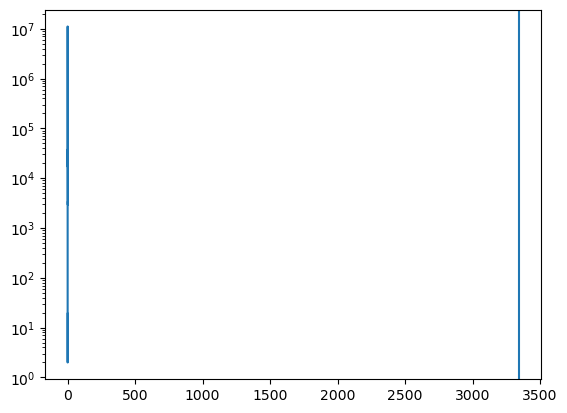

In [40]:
plt.plot(CoSpec[1], CoSpec[-1])
plt.yscale('log')
plt.axvline(3340)

[0.45012728 0.45033179 0.4505363  0.45074081 0.45094532 0.45114983
 0.45135434 0.45155885 0.45176336 0.45196787 0.45217238 0.45237689
 0.4525814  0.45278591 0.45299042 0.45319493 0.45339944 0.45360395
 0.45380846 0.45401298 0.45421749 0.454422   0.45462651 0.45483102
 0.45503553 0.45524004 0.45544455 0.45564906 0.45585357 0.45605808
 0.45626259 0.4564671  0.45667161 0.45687612 0.45708063 0.45728514
 0.45748965 0.45769416 0.45789867 0.45810318 0.45830769 0.4585122
 0.45871671 0.45892122 0.45912573 0.45933024 0.45953475 0.45973926
 0.45994378 0.46014829 0.4603528  0.46055731 0.46076182 0.46096633
 0.46117084 0.46137535 0.46157986 0.46178437 0.46198888 0.46219339
 0.4623979  0.46260241 0.46280692 0.46301143 0.46321594 0.46342045
 0.46362496 0.46382947 0.46403398 0.46423849 0.464443   0.46464751
 0.46485202 0.46505653 0.46526104 0.46546555 0.46567006 0.46587458
 0.46607909 0.4662836  0.46648811 0.46669262 0.46689713 0.46710164
 0.46730615 0.46751066 0.46771517 0.46791968 0.46812419 0.46832

ValueError: Shape of array too small to calculate a numerical gradient, at least (edge_order + 1) elements are required.

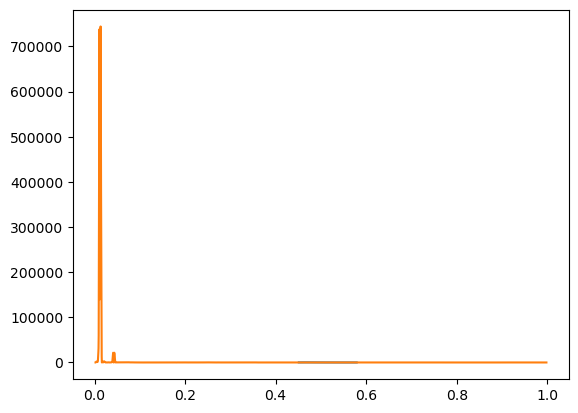

In [52]:
# Calculate compton edge

# Compton Edge Ranges
RangeCs = [0.45,0.58]
RangeCo = [0,1]
RangeNa = [0,1]

Ranges = [RangeCs, RangeCo, RangeNa]
Spectra = [CsSpec, CoSpec, NaSpec]

# Subset data
def Subset(Range, Spec):
    upper = np.where(Spec[1] < Range[1])
    lower = np.where(Spec[1] > Range[0])
    union = np.intersect1d(lower, upper)

    SubsetCounts = Spec[-1,union]
    SubsetEnergy = Spec[1,union]

    return SubsetCounts, SubsetEnergy

# Moving average func
def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

for i in range(3):
    C, E = Subset(Ranges[i],Spectra[i])
    print(E)
    
    # Smooth data
    window=5
    C_smooth = moving_average(C,n=window)
    E_smooth = moving_average(E,n=window)
    
    # Numerical derivative
    dCdE = np.gradient(C_smooth)
    dCdE_S = moving_average(dCdE,7)
    E_smooth = moving_average(E_smooth, 7)
    plt.plot(E_smooth,np.abs(dCdE_S))
    
    # Locate maximum of derivative
    CE = E_smooth[np.argmax(dCdE_S)]

# Report values
CE_ExpCs = 0
CE_ExpCo = 0
CE_ExpNa = 0

print(CE_ExpCs, CE_ExpCo, CE_ExpNa)

In [65]:
### Determine backscatter peak

# Backscatter Ranges
RangeCs = [0.15,0.3]
RangeCo = [0.05,0.2]
RangeNa = [0,1]

Ranges = [RangeCs, RangeCo, RangeNa]

BSE_Vals = [0,0,0]

# Find maximum
for i in range(2):
    C, E = Subset(Ranges[i], Spectra[i])
    BSE = E[np.argmax(C)]
    BSE_Vals[i] = BSE
    
# Save BS energy (BSE)
BSE_Cs = BSE_Vals[0]
BSE_Co = BSE_Vals[1]
BSE_Na = BSE_Vals[2]

### Determine predicted compton edge
CE_Vals = [PP_Cs - BSE_Cs, PP_Co - BSE_Co, PP_Na - BSE_Na]

print(BSE_Vals)
print(CE_Vals)

[0.2006246524671, 0.11209580838323352, 0]
[0.4663753475329, 1.0579041916167664, 1.276]


In [66]:
# Report all numbers
print(f'')
print(f'')
print(f'')

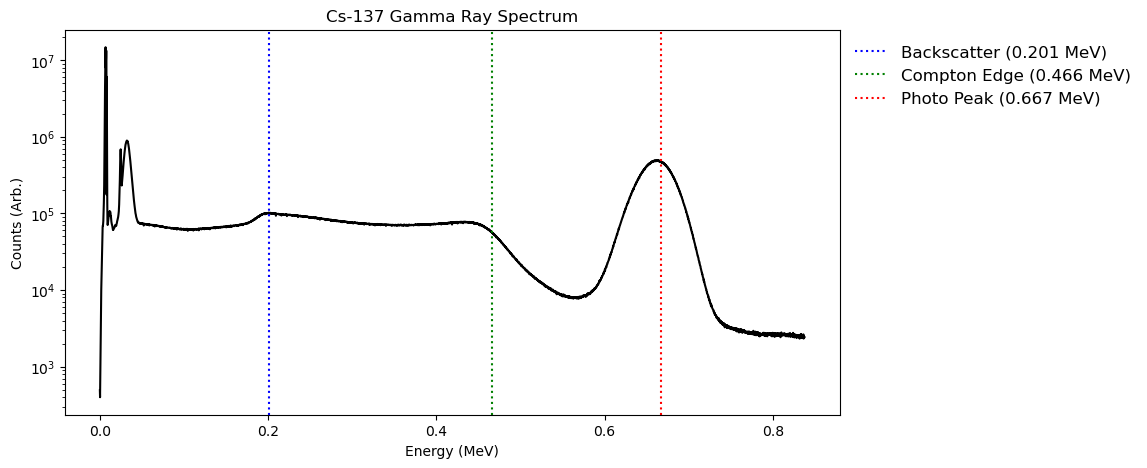

In [ ]:
names = ['Cs-137', 'Co-60', 'Na-22']
spectra = [CsSpec, CoSpec, NaSpec]
bg = [CsBg, CoBg, NaBg]

for i in range(3):
    plt.figure(figsize=(10,5))
    # plt.plot(CsSpec[1],CsSpec[-1] - CsBg[-1],color='black')
    plt.plot(spectra[i][1], spectra[i][-1] - bg[i][-1],color='black')
    plt.yscale('log')
    plt.title(f'{names[i]} Gamma Ray Spectrum') 
    plt.xlabel('Energy (MeV)')
    plt.ylabel('Counts (Arb.)')
    plt.axvline(BSE_Vals[i], linestyle=':', color='blue', label=f'Backscatter ({BSE_Vals[i]:.3f} MeV)')
    plt.axvline(CE_Vals[i], linestyle=':', color='green', label=f'Compton Edge ({CE_Vals[i]:.3f} MeV)')
    plt.axvline(PP_Vals[i], linestyle=':', color='red', label=f'Photo Peak ({PP_Vals[i]} MeV)')
    plt.legend(framealpha=0,bbox_to_anchor=(1,1),fontsize=12)
    plt.savefig(f'./{names[i]}.png',dpi=300,bbox_inches='tight')
    plt.show()

# Mass Absorption

In [18]:
thicknesses = [1.14,0.95,0.76,0.57,0.38,0.19]
lnArea = [1.289692613,1.392259106,1.491026892,1.581774629,1.677753837,1.77761277]

In [29]:
popt, cov = curve_fit(linear, thicknesses, lnArea)

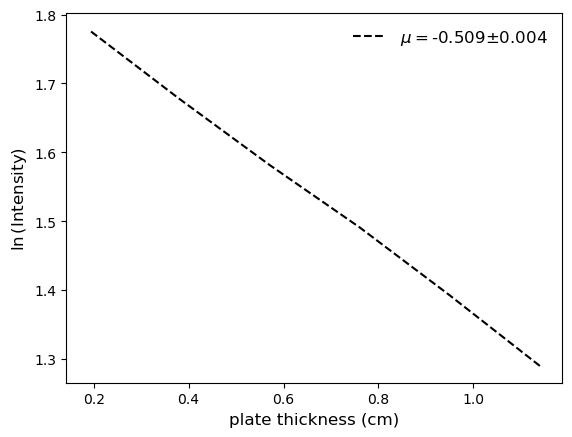

In [45]:
plt.plot(thicknesses, lnArea, linestyle='--',color='black',label=r'$\mu = $' + f'{popt[0]:.3f}' + r'$\pm$' + f'{np.sqrt(cov[0][0]):.3f}')
plt.legend(framealpha=0,fontsize=12)
plt.xlabel('plate thickness (cm)',fontsize=12)
plt.ylabel(r'$\ln$(Intensity)',fontsize=12)
plt.savefig('OUTPUT/massatn.png',dpi=300)
plt.show()